# LUNGCNET FOR LUNG CANCER DETECTION AND CLASSIFICATION



# Library Import

I will be importing the various libraries that will be used during the execution of this project

In [ ]:
import tensorflow as tf #Crucial for Tensorflow
import numpy as np #Crucial for Numpy operations
from matplotlib import pyplot as plt  #Crucial for plotting
import os #This gives access to the Operating system directory
import cv2 #For working with image and video processing functions.
import imghdr #For image
import shutil
import pandas as pd
from PIL import Image
import tensorflow as tf #Crucial for Tensorflow
import tensorflow_hub as hub
from google.colab import drive
import os
import shutil
import pandas as pd
from IPython.display import Image
import matplotlib.pyplot as plt


# Google Drive

All my files are stored in google drive, so, I will be mounting it so as to have access to them from this notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive') #Mounting the drive

Mounted at /content/drive


# Creating A dataframe

The files didn't come with a label, so, I want to create a dataframe that will create a label for each of the file. Meaning, the class they all belong to

In [ ]:
import os
import shutil
import pandas as pd

# Defining the paths to the source and destination directories
source_dirs = [
    "/content/drive/MyDrive/SalfordUniversity/Lung Cancer/Lung Cancer 2/Bengin cases",
    "/content/drive/MyDrive/SalfordUniversity/Lung Cancer/Lung Cancer 2/Malignant cases",
    "/content/drive/MyDrive/SalfordUniversity/Lung Cancer/Lung Cancer 2/Normal cases"
]
destination_dir = "/content/drive/MyDrive/SalfordUniversity/Lung Cancer/Lung Cancer 2/All Cases"

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Move files from source directories to the destination directory
for source_dir in source_dirs:
    for file in os.listdir(source_dir):
        source_path = os.path.join(source_dir, file)
        destination_path = os.path.join(destination_dir, file)
        shutil.move(source_path, destination_path)

# Define a list to store the data
data = []

# Iterate through each file in the destination directory
for file in os.listdir(destination_dir):
    # Extract the file name without the extension
    file_name, _ = os.path.splitext(file)
    # Derive the lung cancer type from the file name
    if "bengin" in file.lower():
        lung_cancer_type = "Benign"
    elif "malignant" in file.lower():
        lung_cancer_type = "Malignant"
    elif "normal" in file.lower():
        lung_cancer_type = "Normal"
    else:
        lung_cancer_type = "Unknown"
    # Append the file name and lung cancer type to the data list
    data.append({"ID": file_name, "Lung Cancer Type": lung_cancer_type})

# Create a DataFrame from the data list
df = pd.DataFrame(data)


# Exploratory Data Analysis

I will be doing some exploratory data analysis
* Class Distribution
* Distribution of pixel intensities
* Distribution of images sizes
* Sample Images

## Class Distribution

A quick look at the number of images in each class

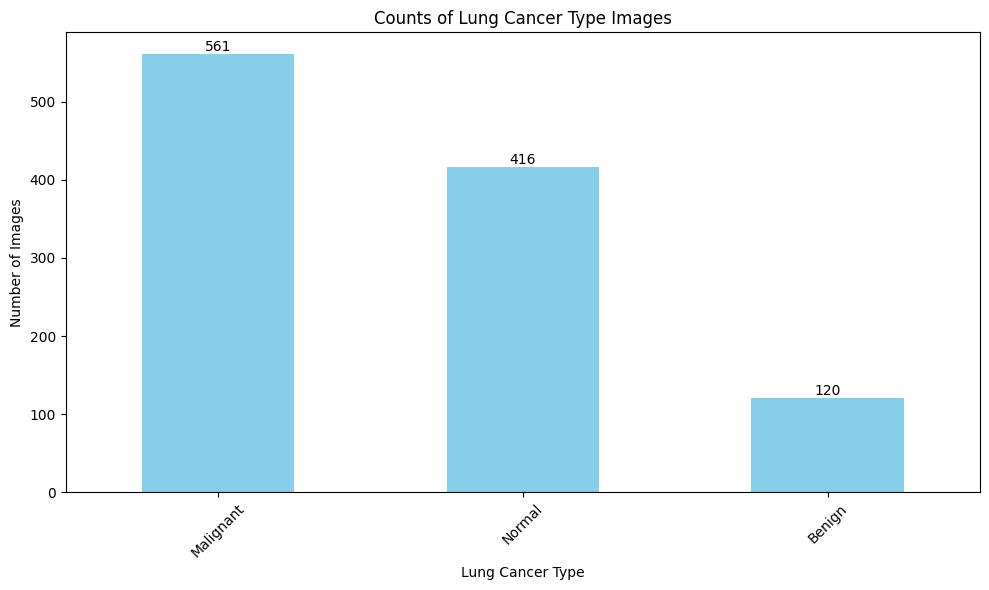

In [ ]:
# Get the value counts of 'Lung Cancer Type'
value_counts = df['Lung Cancer Type'].value_counts()

# Create a bar plot
plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar', color='skyblue')

# Add labels and title
plt.title('Counts of Lung Cancer Type Images')
plt.xlabel('Lung Cancer Type')
plt.ylabel('Number of Images')

# Add annotations for each bar
for i, count in enumerate(value_counts):
    plt.text(i, count, str(count), ha='center', va='bottom')

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Distribution of pixel intensities

Provides a visual representation of the distribution of pixel values in the images

In [ ]:
'''
import random

def visualize_pixel_intensity(file_path, class_name, num_images=None):
    print(f"Visualizing pixel intensity distribution for {class_name} class:")
    pixel_intensity = []
    class_files = os.listdir(file_path)
    if num_images is not None and num_images < len(class_files):
        class_files = random.sample(class_files, num_images)  # Randomly select a subset of images
    for file_name in class_files:
        image = cv2.imread(os.path.join(file_path, file_name), cv2.IMREAD_GRAYSCALE)
        pixel_intensity.extend(image.flatten())
    plt.figure(figsize=(10, 5))
    plt.hist(pixel_intensity, bins=50, color='blue', alpha=0.7)
    plt.title(f"Pixel Intensity Distribution for {class_name}")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# Specify the maximum number of images to process for each class
max_images_per_class = 120

# Path to the folder containing all images
all_cases_file_path = "/content/drive/MyDrive/SalfordUniversity/Lung Cancer/All Cases"

# Visualize pixel intensity distribution for each class (limiting to max_images_per_class)
visualize_pixel_intensity(all_cases_file_path, "All Cases", num_images=max_images_per_class)
'''

'\nimport random\n\ndef visualize_pixel_intensity(file_path, class_name, num_images=None):\n    print(f"Visualizing pixel intensity distribution for {class_name} class:")\n    pixel_intensity = []\n    class_files = os.listdir(file_path)\n    if num_images is not None and num_images < len(class_files):\n        class_files = random.sample(class_files, num_images)  # Randomly select a subset of images\n    for file_name in class_files:\n        image = cv2.imread(os.path.join(file_path, file_name), cv2.IMREAD_GRAYSCALE)\n        pixel_intensity.extend(image.flatten())\n    plt.figure(figsize=(10, 5))\n    plt.hist(pixel_intensity, bins=50, color=\'blue\', alpha=0.7)\n    plt.title(f"Pixel Intensity Distribution for {class_name}")\n    plt.xlabel("Pixel Intensity")\n    plt.ylabel("Frequency")\n    plt.grid(True)\n    plt.show()\n\n# Specify the maximum number of images to process for each class\nmax_images_per_class = 120\n\n# Path to the folder containing all images\nall_cases_file_pat

## Distribution of images sizes

Checking the image size

In [ ]:

'''
def get_image_sizes(folder_path):
    image_sizes = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".jpg") or filename.endswith(".png"):  # Adjust file extensions as needed
            image_path = os.path.join(folder_path, filename)
            image = cv2.imread(image_path)
            if image is not None:
                height, width, _ = image.shape  # For color images
                # For grayscale images, use: height, width = image.shape
                image_sizes.append((width, height))
    return image_sizes

def visualize_image_size_distribution(image_sizes, class_name):
    widths = [size[0] for size in image_sizes]
    heights = [size[1] for size in image_sizes]

    plt.figure(figsize=(10, 6))
    plt.hist(widths, bins=50, color='blue', alpha=0.7, label='Width')
    plt.hist(heights, bins=50, color='red', alpha=0.7, label='Height')
    plt.title(f"Image Size Distribution for {class_name} Class")
    plt.xlabel("Size (pixels)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

# Path to the folder containing all images
all_cases_file_path = "/content/drive/MyDrive/SalfordUniversity/Lung Cancer/All Cases"

# Example usage:
all_cases_image_sizes = get_image_sizes(all_cases_file_path)
visualize_image_size_distribution(all_cases_image_sizes, "All Cases")

'''


'\ndef get_image_sizes(folder_path):\n    image_sizes = []\n    for filename in os.listdir(folder_path):\n        if filename.endswith(".jpg") or filename.endswith(".png"):  # Adjust file extensions as needed\n            image_path = os.path.join(folder_path, filename)\n            image = cv2.imread(image_path)\n            if image is not None:\n                height, width, _ = image.shape  # For color images\n                # For grayscale images, use: height, width = image.shape\n                image_sizes.append((width, height))\n    return image_sizes\n\ndef visualize_image_size_distribution(image_sizes, class_name):\n    widths = [size[0] for size in image_sizes]\n    heights = [size[1] for size in image_sizes]\n\n    plt.figure(figsize=(10, 6))\n    plt.hist(widths, bins=50, color=\'blue\', alpha=0.7, label=\'Width\')\n    plt.hist(heights, bins=50, color=\'red\', alpha=0.7, label=\'Height\')\n    plt.title(f"Image Size Distribution for {class_name} Class")\n    plt.xlabel

## Sample Images

Showing 4 sample images for each class

In [ ]:
'''
# Function to visualize sample images for each lung cancer type
def visualize_samples_from_df(df, all_cases_folder, num_samples_per_class=4):
    # Get unique lung cancer types
    unique_types = df['Lung Cancer Type'].unique()

    plt.figure(figsize=(15, 5))

    for i, cancer_type in enumerate(unique_types):
        # Filter dataframe for the current lung cancer type
        type_df = df[df['Lung Cancer Type'] == cancer_type]

        # Randomly select num_samples_per_class images for the current lung cancer type
        sampled_files = random.sample(type_df['ID'].tolist(), min(num_samples_per_class, len(type_df)))

        for j, file_name in enumerate(sampled_files):
            # Read and display the image
            image = cv2.imread(os.path.join('/content/drive/MyDrive/SalfordUniversity/Lung Cancer/All Cases', file_name + '.jpg'))  # Assuming all images are in JPG format
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            plt.subplot(len(unique_types), num_samples_per_class, i * num_samples_per_class + j + 1)
            plt.imshow(image)
            plt.title(f"{cancer_type} Sample {j + 1}")
            plt.axis('off')

    plt.show()

# Call the function to visualize sample images
visualize_samples_from_df(df, '/content/drive/MyDrive/SalfordUniversity/Lung Cancer/All Cases', num_samples_per_class=4)
'''


'\n# Function to visualize sample images for each lung cancer type\ndef visualize_samples_from_df(df, all_cases_folder, num_samples_per_class=4):\n    # Get unique lung cancer types\n    unique_types = df[\'Lung Cancer Type\'].unique()\n\n    plt.figure(figsize=(15, 5))\n\n    for i, cancer_type in enumerate(unique_types):\n        # Filter dataframe for the current lung cancer type\n        type_df = df[df[\'Lung Cancer Type\'] == cancer_type]\n\n        # Randomly select num_samples_per_class images for the current lung cancer type\n        sampled_files = random.sample(type_df[\'ID\'].tolist(), min(num_samples_per_class, len(type_df)))\n\n        for j, file_name in enumerate(sampled_files):\n            # Read and display the image\n            image = cv2.imread(os.path.join(\'/content/drive/MyDrive/SalfordUniversity/Lung Cancer/All Cases\', file_name + \'.jpg\'))  # Assuming all images are in JPG format\n            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)\n            plt.

# Data Preprocessing

In this stage, I will be looking at the following
* Creating a filenames
* Converting Lung Cancer type to labels
* File Confirmation
* Unique label
* Label to Boolen
* Data Splitting
* Process Image
* Get Image Label
* Batch Processing
* Train and Validation Data

## File Names

Creating a filename list which will contain all the files in the All cases folder

In [ ]:
 #Filenames
filenames = ["/content/drive/MyDrive/SalfordUniversity/Lung Cancer/Lung Cancer 2/All Cases/" + fnames + ".jpg" for fnames in df["ID"]]
filenames[1]

'/content/drive/MyDrive/SalfordUniversity/Lung Cancer/Lung Cancer 2/All Cases/Bengin case (70).jpg'

## Label Conversion

Converting the various lung cancer types to numpy array

In [ ]:
#converting the labels to numpy
import numpy as np

labels = df["Lung Cancer Type"].to_numpy()
labels

array(['Benign', 'Benign', 'Benign', ..., 'Benign', 'Benign', 'Benign'],
      dtype=object)

## File Confirmation

Checking to see if the files and labels are the same number. This is to make sure each file has the corresponding label

In [ ]:
#checking to see if the number of files and labels are equal
if len(filenames) == len(labels):
  print("Number of filenames matches labels ")
else:
  print("Number of filenames doesn't match labels ")

Number of filenames matches labels 


## Unique Label

I'm creating an numpy array that's goung to hold the unique class(Label)

In [ ]:
#listing the unique labels
unique_cancer = np.unique(labels)
unique_cancer

array(['Benign', 'Malignant', 'Normal'], dtype=object)

## Label to Boolen

What happens here is, for every record in the dataframe, the label shows which class it belongs but indicating if it's true or false based on the position it is on the unique cancer label.

```
If row 2 is Benign, Unique_cancer will have ['Benign', 'Malignant', 'Normal']
while boolean_labels will have [True, False, False] because Benign is in index 0
```




In [ ]:
#converting labels to boolean
boolean_labels  = [label == unique_cancer for label in labels]
boolean_labels[2]

array([ True, False, False])

## Data Splitting

I will be slippiting the data to train and test set

In [ ]:
#Splitting data

X = filenames #filename list created
y = boolean_labels #boolean label for each filename

# Number of images to process
NUM_IMAGES = 2000 #@param {type: "slider", min:1000 , max:10000, step: 1000}

#Splitting the data
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X[:NUM_IMAGES],
                                                  y[:NUM_IMAGES],
                                                  test_size = 0.2,
                                                  random_state=42 # this will make it random
                                                  )

len(X_train), len(y_train), len(X_val), len(y_val)

(877, 877, 220, 220)

## Process Image

Here are some of the key data processing steps that occur in the process_images function:
1. Image file reading:
  * The function takes an image_path as input, which represents the file path of the image.
  * It uses tf.io.read_file() to read the image file from the specified path.
2. Image decoding:
  * The image file is decoded into a tensor using tf.image.decode_jpeg().
  * The channels parameter is set to 3, indicating that the image should have 3
    color channels (RGB).
3. Gaussian blur:
  * The gaussian_blur() function is applied to the decoded image tensor.
  * It takes the image, kernel size (5 in this case), and sigma value (1.0) as input.
  * The Gaussian blur is implemented using tf.nn.conv2d() by convolving the image with a Gaussian kernel.
4. Data augmentation (optional):
  * If the augment parameter is set to True, various data augmentation techniques are applied to the image.
  * These techniques include random flips (left-right and up-down), random brightness and contrast adjustments, random rotations, random cropping, random saturation and hue adjustments, random zoom, and random shear.
  * The specific augmentation operations are performed using TensorFlow's image processing functions from the tf.image module.
5. Normalization:
  * The pixel values of the image are normalized from the range [0, 255] to [0, 1] using tf.image.convert_image_dtype().
  * This is done to scale the pixel values to a consistent range that is suitable for input to neural networks.
6. Resizing:
  * The image is resized to a specified size (img_size) using tf.image.resize().
  * This ensures that all images have a consistent size before being fed into the model.
7. Tensor output:
  * Finally, the processed image tensor is returned as the output of the function.
  * This tensor can be used as input to a machine learning model or further processed as needed.

In [ ]:
IMG_SIZE = 256 #default image size




def process_images(image_path, img_size=IMG_SIZE, augment=True, augmentation_options=None):
    """
    Take an image file path and turn it into a tensor, with optional data augmentation.

    Args:
    - image_path: Path to the image file
    - img_size: Size to which the image should be resized
    - augment: Whether to apply data augmentation
    - augmentation_options: Dict with parameters for specific augmentations

    Returns:
    - Processed image tensor
    """
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    if augment:
        if augmentation_options is None:
            augmentation_options = {}

        # Random flipping
        if augmentation_options.get('flip_horizontal', True):
            image = tf.image.random_flip_left_right(image)
        if augmentation_options.get('flip_vertical', False):
            image = tf.image.random_flip_up_down(image)

        # Random brightness and contrast
        if 'brightness' in augmentation_options:
            image = tf.image.random_brightness(image, max_delta=augmentation_options['brightness'])
        if 'contrast' in augmentation_options:
            lower, upper = augmentation_options['contrast']
            image = tf.image.random_contrast(image, lower=lower, upper=upper)

        # Additional augmentations
        if 'rotation' in augmentation_options:
            image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
        if 'zoom' in augmentation_options:
            scales = augmentation_options['zoom']  # Example: [0.8, 1.2]
            image = tf.image.central_crop(image, tf.random.uniform(shape=[], minval=scales[0], maxval=scales[1]))

    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    return image


'\ndef process_images(image_path, img_size=IMG_SIZE, augment=True):\n    """\n    Take an image file path and turn it into a tensor, with optional data augmentation.\n\n    Args:\n    - image_path: Path to the image file\n    - img_size: Size to which the image should be resized (default is IMG_SIZE)\n    - augment: Whether to apply data augmentation (default is False)\n\n    Returns:\n    - Processed image tensor\n    """\n    # Read in the image file\n    image = tf.io.read_file(image_path)\n\n    # Decode the image into a Tensor (turn the jpeg image into numerical tensor with 3 color channels (RGB Red Green Blue))\n    image = tf.image.decode_jpeg(image, channels=3)\n\n    if augment:\n        # Apply data augmentation techniques\n        image = tf.image.random_flip_left_right(image)\n        image = tf.image.random_flip_up_down(image)\n        image = tf.image.random_brightness(image, max_delta=0.2)\n        image = tf.image.random_contrast(image, lower=0.5, upper=1.5)\n        # 

## Image Label

This will return the image and label of an image path passed to it in a tuple form

In [ ]:


def get_image_label(image_path, label=None, augment=False):
    """
    Return image and label in a tuple, with optional augmentation.

    Args:
    - image_path: Path to the image file
    - label: Optional label associated with the image (default is None)
    - augment: Boolean, whether to apply data augmentation (default is False)

    Returns:
    - Tuple containing processed image tensor and label (if provided)
    """
    image = process_images(image_path, augment=augment)
    if label is not None:
        return (image, label)
    else:
        return image



## Image Batch processing

This function turns the data into batches

In [ ]:
#processing images in batches

#define batch size
BATCH_SIZE = 32

def create_data_batches(X, y=None, batch_size=BATCH_SIZE, valid_data=False, test_data=False):
    """
    Creates batches of data out of image(X) and label(y) pairs.
    Shuffles the data if it's training data and no shuffling if it's validation/test data.
    Accepts test data as input (no label).
    """
    # Configure augmentation based on the data type
    augment = not (valid_data or test_data)  # Enable augmentation for training data only

    if test_data:
        print("Creating test data batches...")
        data = tf.data.Dataset.from_tensor_slices((tf.constant(X)))  # Only filepaths, no labels
        data_batch = data.map(lambda x: get_image_label(x, augment=augment)).batch(batch_size)
        return data_batch

    elif valid_data:
        print("Creating validation data batches...")
        data = tf.data.Dataset.from_tensor_slices((tf.constant(X), tf.constant(y)))
        data_batch = data.map(lambda x, y: get_image_label(x, y, augment=augment)).batch(batch_size)
        return data_batch

    else:
        print("Creating training data batches...")
        data = tf.data.Dataset.from_tensor_slices((tf.constant(X), tf.constant(y)))
        data = data.shuffle(buffer_size=len(X))
        data_batch = data.map(lambda x, y: get_image_label(x, y, augment=augment)).batch(batch_size)
        return data_batch




## Training and Validation Data

Creating the training and validation data that the models will use

In [ ]:
#train  and validation batches

train_data = create_data_batches(X_train, y_train)

val_data = create_data_batches(X_val, y_val, valid_data = True)

Creating training data batches...
Creating validation data batches...


## Tensorboard Callbard

This is for monitoring each model's performance

In [ ]:
#creating a Tensorboard callback(Monitors model's performance)
%load_ext tensorboard

import datetime
#tensorboard call back function
def create_tensorboard_callback():
  #create a log directory for storing the tensorboard log
  logdir = os.path.join("/content/drive/MyDrive/Image Classification/pets/logs/",
                        datetime.datetime.now().strftime("%Y%m%d - %H%M%S") #Keeps track of the log time
  )
  return tf.keras.callbacks.TensorBoard(logdir)


#Preventing overfitting when a evaluation metric stops improving
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = "val_accuracy",
                                                  patience = 3)

# Training the model

NUM_EPOCHS = 90 #@param {type:"slider", min:10, max:100, step:10}

# Building and Training the models

In this session, I will be building the following models:

* LungCNet
* VGG16


In [ ]:
LEARNING_RATE = 0.0001

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization


In [ ]:
'''
def create_improved_LungCNET_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), output_shape=len(unique_cancer), learning_rate=LEARNING_RATE):
    # Initialize the model
    LungCNET = Sequential()

    # Add convolutional layers with Batch Normalization and Dropout
    LungCNET.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    LungCNET.add(BatchNormalization())
    LungCNET.add(MaxPooling2D((2, 2)))
    LungCNET.add(Dropout(0.25))

    LungCNET.add(Conv2D(64, (3, 3), activation='relu'))
    LungCNET.add(BatchNormalization())
    LungCNET.add(MaxPooling2D((2, 2)))
    LungCNET.add(Dropout(0.25))

    LungCNET.add(Conv2D(128, (3, 3), activation='relu'))
    LungCNET.add(BatchNormalization())
    LungCNET.add(MaxPooling2D((2, 2)))
    LungCNET.add(Dropout(0.25))

    # Add additional convolutional layers to increase model capacity
    LungCNET.add(Conv2D(256, (3, 3), activation='relu'))
    LungCNET.add(BatchNormalization())
    LungCNET.add(MaxPooling2D((2, 2)))
    LungCNET.add(Dropout(0.25))

    LungCNET.add(Conv2D(512, (3, 3), activation='relu'))
    LungCNET.add(BatchNormalization())
    LungCNET.add(MaxPooling2D((2, 2)))
    LungCNET.add(Dropout(0.25))

    # Flatten layer
    LungCNET.add(Flatten())

    # Dense (fully connected) layers with Dropout
    LungCNET.add(Dense(1024, activation='relu'))
    LungCNET.add(Dropout(0.5))

    LungCNET.add(Dense(output_shape, activation='softmax'))

    # Compile the model with the specified learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    LungCNET.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return LungCNET


# Train LungCNET Model
lungCNET_model = create_improved_LungCNET_model()

# Define learning rate schedule
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=LEARNING_RATE,
    decay_steps=10000,
    decay_rate=0.96,
    staircase=True)

# Compile the model with the learning rate schedule
lungCNET_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

lungCNET_model_history = lungCNET_model.fit(train_data,
                                             epochs=NUM_EPOCHS,
                                             validation_data=val_data,
                                             callbacks=[create_tensorboard_callback(), early_stopping])

print("LungCNET Model Training Completed")


print("Improved LungCNET Model Built")
'''

def create_improved_LungCNET_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), output_shape=len(unique_cancer)):
    lungCNET = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(output_shape, activation='softmax')
    ])
    return lungCNET

# Define learning rate schedule
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=LEARNING_RATE,
    decay_steps=10000,
    decay_rate=0.96,
    staircase=True)

# Create the model
lungCNET_model = create_improved_LungCNET_model((IMG_SIZE, IMG_SIZE, 3), len(unique_cancer))

# Compile the model with the learning rate schedule
lungCNET_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# Define callbacks (make sure to define or import create_tensorboard_callback and early_stopping functions)
callbacks = [create_tensorboard_callback(), early_stopping]

# Train the model
lungCNET_model_history = lungCNET_model.fit(
    train_data,
    epochs=NUM_EPOCHS,
    validation_data=val_data,
    callbacks=callbacks)

print("LungCNET Model Training Completed")



Epoch 1/90
28/28 [==============================] - 39s 286ms/step - loss: 1.0583 - accuracy: 0.5222 - val_loss: 0.9057 - val_accuracy: 0.5636
Epoch 2/90
28/28 [==============================] - 6s 207ms/step - loss: 0.8455 - accuracy: 0.6271 - val_loss: 0.8043 - val_accuracy: 0.5909
Epoch 3/90
28/28 [==============================] - 6s 206ms/step - loss: 0.7216 - accuracy: 0.6921 - val_loss: 0.7037 - val_accuracy: 0.7136
Epoch 4/90
28/28 [==============================] - 6s 207ms/step - loss: 0.6207 - accuracy: 0.7594 - val_loss: 0.6419 - val_accuracy: 0.7000
Epoch 5/90
28/28 [==============================] - 6s 196ms/step - loss: 0.5255 - accuracy: 0.7891 - val_loss: 0.4987 - val_accuracy: 0.7864
Epoch 6/90
28/28 [==============================] - 6s 202ms/step - loss: 0.4295 - accuracy: 0.8404 - val_loss: 0.3911 - val_accuracy: 0.8864
Epoch 7/90
28/28 [==============================] - 5s 190ms/step - loss: 0.3575 - accuracy: 0.8677 - val_loss: 0.3473 - val_accuracy: 0.8773
Epoch

## VGG16

In [ ]:
def create_fine_tuned_vgg16_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), output_shape=len(unique_cancer), num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE):
    # Load the VGG16 base model with pre-trained weights
    base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

    # Unfreeze the last 4 layers of the base model
    for layer in base_model.layers[-4:]:
        layer.trainable = True

    # Add custom classification head
    global_average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    output_layer = tf.keras.layers.Dense(output_shape, activation='softmax')(global_average_pooling_layer)

    # Create the fine-tuned model
    model = tf.keras.Model(inputs=base_model.input, outputs=output_layer)

    # Compile the model with a smaller learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Define learning rate schedule
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=learning_rate,
        decay_steps=10000,
        decay_rate=0.96,
        staircase=True)

    # Compile the model with the learning rate schedule
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    # Fine-tune the model
    model_history = model.fit(train_data,
                              epochs=num_epochs,
                              validation_data=val_data,
                              callbacks=[create_tensorboard_callback(), early_stopping])

    return model, model_history

# Create and fine-tune the VGG16 model
vgg16_model, vgg16_model_history = create_fine_tuned_vgg16_model()
print("Fine-tuned VGG16 Model Completed")



58889256/58889256 [==============================] - 2s 0us/step
Epoch 1/90
28/28 [==============================] - 22s 403ms/step - loss: 0.9071 - accuracy: 0.5975 - val_loss: 0.6519 - val_accuracy: 0.7182
Epoch 2/90
28/28 [==============================] - 6s 204ms/step - loss: 0.4620 - accuracy: 0.8404 - val_loss: 0.3514 - val_accuracy: 0.8682
Epoch 3/90
28/28 [==============================] - 6s 207ms/step - loss: 0.4002 - accuracy: 0.8518 - val_loss: 0.3528 - val_accuracy: 0.8636
Epoch 4/90
28/28 [==============================] - 6s 211ms/step - loss: 0.3270 - accuracy: 0.8700 - val_loss: 0.3630 - val_accuracy: 0.8500
Epoch 5/90
28/28 [==============================] - 6s 200ms/step - loss: 0.2745 - accuracy: 0.8848 - val_loss: 0.7579 - val_accuracy: 0.7773
Fine-tuned VGG16 Model Completed


## Resnet 50

In [ ]:
def fine_tune_resnet50_model(train_data, val_data, num_epochs, initial_learning_rate=LEARNING_RATE):
    # Load the ResNet50 base model with pre-trained weights
    base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

    # Unfreeze the last 10 layers of the base model
    for layer in base_model.layers[-10:]:
        layer.trainable = True

    # Add custom classification head
    global_average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    output_layer = tf.keras.layers.Dense(len(unique_cancer), activation='softmax')(global_average_pooling_layer)

    # Create the fine-tuned model
    resnet50_model = tf.keras.Model(inputs=base_model.input, outputs=output_layer)

    # Define learning rate schedule
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=initial_learning_rate,
        decay_steps=10000,
        decay_rate=0.96,
        staircase=True)

    # Compile the model with the learning rate schedule
    resnet50_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    # Define callbacks
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    learning_rate_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=5)

    # Train the model
    resnet50_model_history = resnet50_model.fit(train_data,
                                                epochs=num_epochs,
                                                validation_data=val_data,
                                                callbacks=[early_stopping, learning_rate_scheduler])

    return resnet50_model, resnet50_model_history

# Fine-tune ResNet50 Model
resnet50_model, resnet50_model_history = fine_tune_resnet50_model(train_data, val_data, NUM_EPOCHS, LEARNING_RATE)
print("ResNet50 Model Fine-tuning Completed")


94765736/94765736 [==============================] - 3s 0us/step
Epoch 1/90
28/28 [==============================] - 40s 326ms/step - loss: 0.2597 - accuracy: 0.9054 - val_loss: 0.9960 - val_accuracy: 0.4909 - lr: 1.0000e-04
Epoch 2/90
28/28 [==============================] - 6s 200ms/step - loss: 0.0427 - accuracy: 0.9863 - val_loss: 1.0847 - val_accuracy: 0.3500 - lr: 1.0000e-04
Epoch 3/90
28/28 [==============================] - 6s 206ms/step - loss: 0.0133 - accuracy: 0.9977 - val_loss: 1.0915 - val_accuracy: 0.3818 - lr: 1.0000e-04
Epoch 4/90
28/28 [==============================] - 6s 201ms/step - loss: 0.0344 - accuracy: 0.9909 - val_loss: 0.9710 - val_accuracy: 0.5273 - lr: 1.0000e-04
Epoch 5/90
28/28 [==============================] - 6s 210ms/step - loss: 0.0423 - accuracy: 0.9840 - val_loss: 1.9672 - val_accuracy: 0.5318 - lr: 1.0000e-04
Epoch 6/90
28/28 [==============================] - 6s 199ms/step - loss: 0.0137 - accuracy: 0.9943 - val_loss: 2.3532 - val_accuracy: 0.53

## Inceptionv3

In [ ]:
def fine_tune_inceptionv3_model(train_data, val_data, num_epochs, initial_learning_rate=LEARNING_RATE):
    # Load the InceptionV3 base model with pre-trained weights
    base_model = tf.keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

    # Unfreeze the last 20 layers of the base model
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    # Add custom classification head
    global_average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    output_layer = tf.keras.layers.Dense(len(unique_cancer), activation='softmax')(global_average_pooling_layer)

    # Create the fine-tuned model
    inceptionv3_model = tf.keras.Model(inputs=base_model.input, outputs=output_layer)

    # Define learning rate schedule
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=initial_learning_rate,
        decay_steps=10000,
        decay_rate=0.96,
        staircase=True)

    # Compile the model with the learning rate schedule
    inceptionv3_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    # Define callbacks
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    learning_rate_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=2)

    # Train the model
    inceptionv3_model_history = inceptionv3_model.fit(train_data,
                                                      epochs=num_epochs,
                                                      validation_data=val_data,
                                                      callbacks=[early_stopping, learning_rate_scheduler])

    return inceptionv3_model, inceptionv3_model_history

# Fine-tune InceptionV3 Model
inceptionv3_model, inceptionv3_model_history = fine_tune_inceptionv3_model(train_data, val_data, NUM_EPOCHS, LEARNING_RATE)
print("InceptionV3 Model Fine-tuning Completed")


87910968/87910968 [==============================] - 3s 0us/step
Epoch 1/90
28/28 [==============================] - 44s 388ms/step - loss: 0.3761 - accuracy: 0.8426 - val_loss: 0.7296 - val_accuracy: 0.7591 - lr: 1.0000e-04
Epoch 2/90
28/28 [==============================] - 6s 201ms/step - loss: 0.0603 - accuracy: 0.9761 - val_loss: 0.7934 - val_accuracy: 0.7773 - lr: 1.0000e-04
Epoch 3/90
28/28 [==============================] - 6s 206ms/step - loss: 0.0353 - accuracy: 0.9886 - val_loss: 0.7493 - val_accuracy: 0.7773 - lr: 1.0000e-04
Epoch 4/90
28/28 [==============================] - 6s 208ms/step - loss: 0.0679 - accuracy: 0.9749 - val_loss: 0.8733 - val_accuracy: 0.7045 - lr: 1.0000e-04
InceptionV3 Model Fine-tuning Completed


## Mobilenet v2

In [ ]:
def fine_tune_mobilenetv2_model(train_data, val_data, num_epochs, initial_learning_rate=LEARNING_RATE):
    # Load the MobileNetV2 base model with pre-trained weights
    base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

    # Unfreeze the last 10 layers of the base model
    for layer in base_model.layers[-10:]:
        layer.trainable = True

    # Add custom classification head
    global_average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
    output_layer = tf.keras.layers.Dense(len(unique_cancer), activation='softmax')(global_average_pooling_layer)

    # Create the fine-tuned model
    mobilenetv2_model = tf.keras.Model(inputs=base_model.input, outputs=output_layer)

    # Define learning rate schedule
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=initial_learning_rate,
        decay_steps=10000,
        decay_rate=0.96,
        staircase=True)

    # Compile the model with the learning rate schedule
    mobilenetv2_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    # Define callbacks
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    learning_rate_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=2)

    # Train the model
    mobilenetv2_model_history = mobilenetv2_model.fit(train_data,
                                                      epochs=num_epochs,
                                                      validation_data=val_data,
                                                      callbacks=[early_stopping, learning_rate_scheduler])

    return mobilenetv2_model, mobilenetv2_model_history

# Fine-tune MobileNetV2 Model
mobilenetv2_model, mobilenetv2_model_history = fine_tune_mobilenetv2_model(train_data, val_data, NUM_EPOCHS, LEARNING_RATE)
print("MobileNetV2 Model Fine-tuning Completed")

9406464/9406464 [==============================] - 1s 0us/step
Epoch 1/90
28/28 [==============================] - 31s 274ms/step - loss: 0.4018 - accuracy: 0.8415 - val_loss: 0.5651 - val_accuracy: 0.7682 - lr: 1.0000e-04
Epoch 2/90
28/28 [==============================] - 6s 201ms/step - loss: 0.1044 - accuracy: 0.9681 - val_loss: 0.9593 - val_accuracy: 0.5136 - lr: 1.0000e-04
Epoch 3/90
28/28 [==============================] - 6s 196ms/step - loss: 0.0455 - accuracy: 0.9932 - val_loss: 1.1300 - val_accuracy: 0.5273 - lr: 1.0000e-04
Epoch 4/90
28/28 [==============================] - 6s 206ms/step - loss: 0.0291 - accuracy: 0.9943 - val_loss: 0.8324 - val_accuracy: 0.7000 - lr: 1.0000e-04
MobileNetV2 Model Fine-tuning Completed


# Model Performance

         Model  Train Accuracy  Validation Accuracy  Train Loss  \
0     LungCNET        0.981756             0.977273    0.071803   
1        VGG16        0.884835             0.868182    0.274464   
2     ResNet50        0.997720             0.531818    0.005469   
3  InceptionV3        0.988598             0.777273    0.035276   
4  MobileNetV2        0.994299             0.768182    0.029118   

   Validation Loss  
0         0.101613  
1         0.351362  
2         0.970990  
3         0.729583  
4         0.565148  


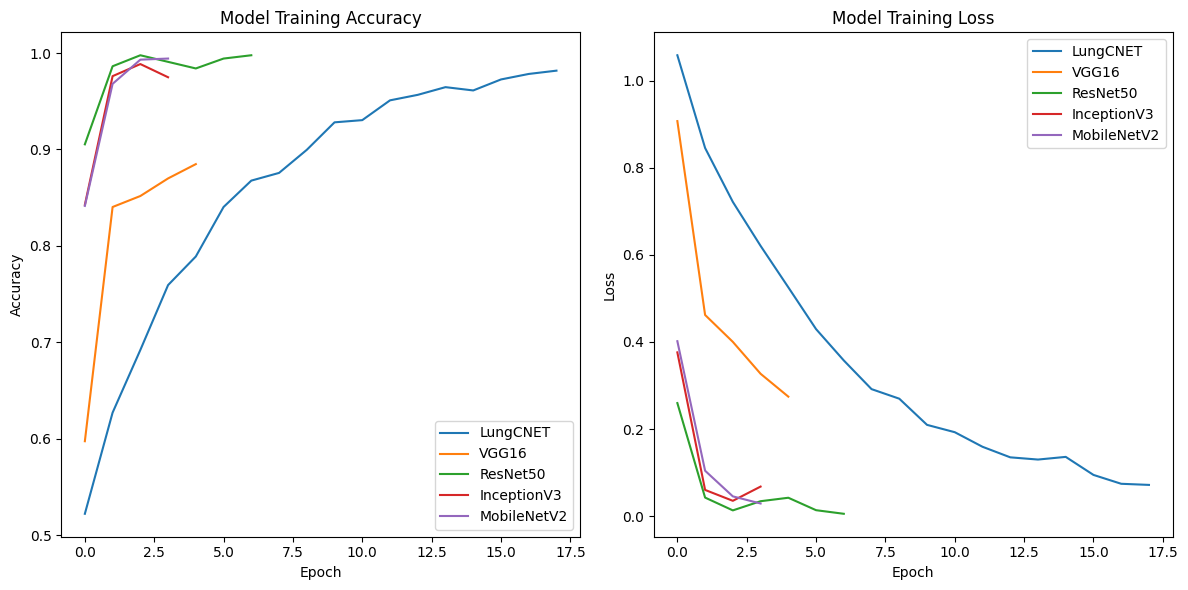

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the models and their histories
models = [
    ("LungCNET", lungCNET_model_history),
    ("VGG16", vgg16_model_history),
    ("ResNet50", resnet50_model_history),
    ("InceptionV3", inceptionv3_model_history),
    ("MobileNetV2", mobilenetv2_model_history)
]

# Extract metrics for each model
metrics = []
for model_name, history in models:
    metrics.append({
        "Model": model_name,
        "Train Accuracy": max(history.history['accuracy']),
        "Validation Accuracy": max(history.history['val_accuracy']),
        "Train Loss": min(history.history['loss']),
        "Validation Loss": min(history.history['val_loss'])
    })

# Create DataFrame from metrics
metrics_df = pd.DataFrame(metrics)

# Display metrics
print(metrics_df)

# Plot performance metrics
plt.figure(figsize=(12, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
for model_name, history in models:
    plt.plot(history.history['accuracy'], label=model_name)
plt.title('Model Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
for model_name, history in models:
    plt.plot(history.history['loss'], label=model_name)
plt.title('Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


7/7 [==============================] - 0s 66ms/step


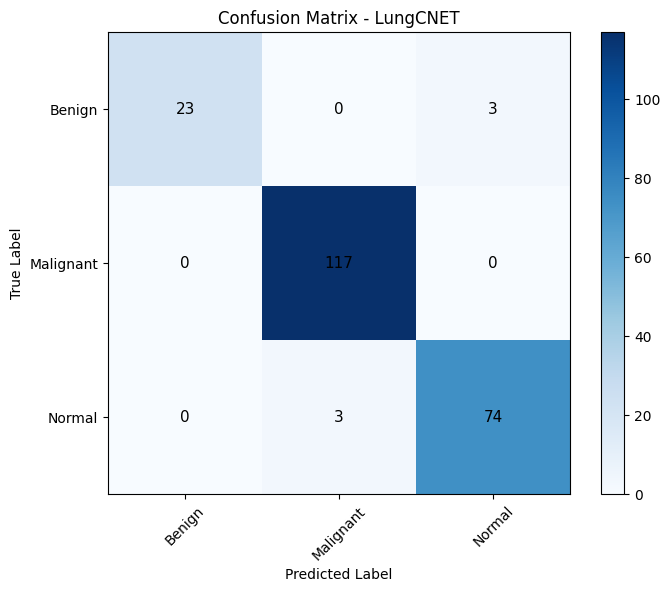

Classification Report - LungCNET:
              precision    recall  f1-score   support

      Benign       1.00      0.88      0.94        26
   Malignant       0.97      1.00      0.99       117
      Normal       0.96      0.96      0.96        77

    accuracy                           0.97       220
   macro avg       0.98      0.95      0.96       220
weighted avg       0.97      0.97      0.97       220



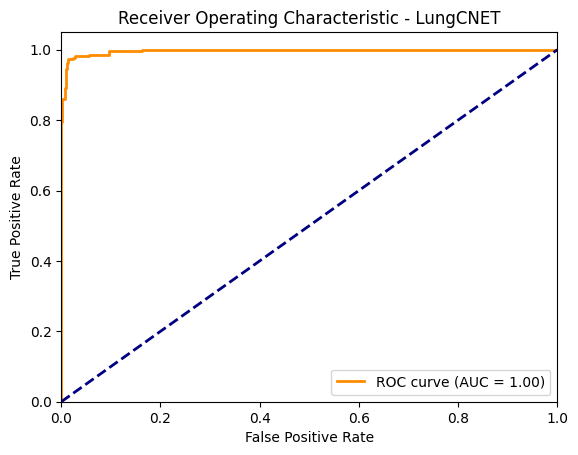

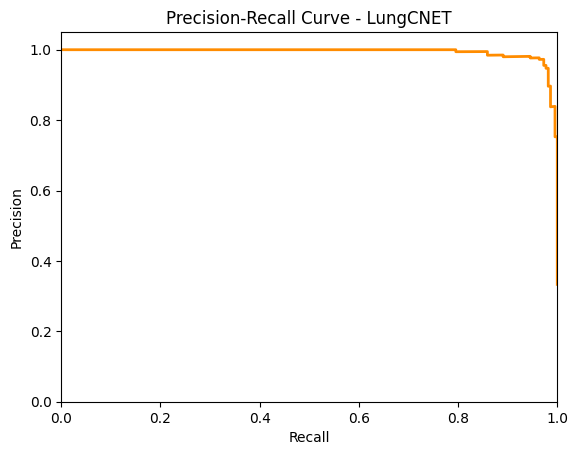

7/7 [==============================] - 0s 61ms/step


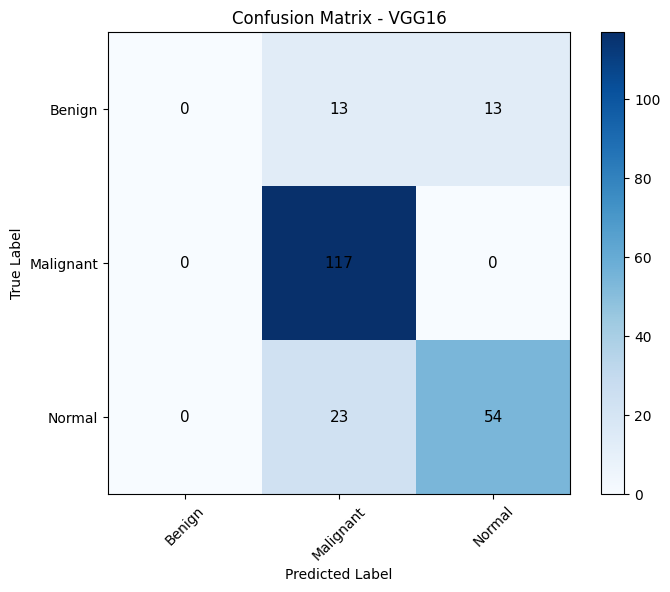

Classification Report - VGG16:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00        26
   Malignant       0.76      1.00      0.87       117
      Normal       0.81      0.70      0.75        77

    accuracy                           0.78       220
   macro avg       0.52      0.57      0.54       220
weighted avg       0.69      0.78      0.72       220



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


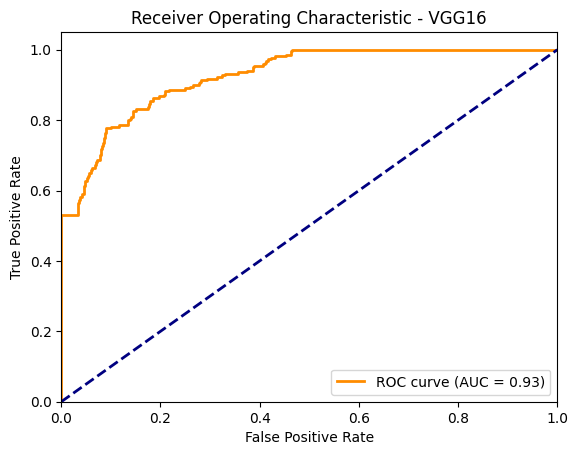

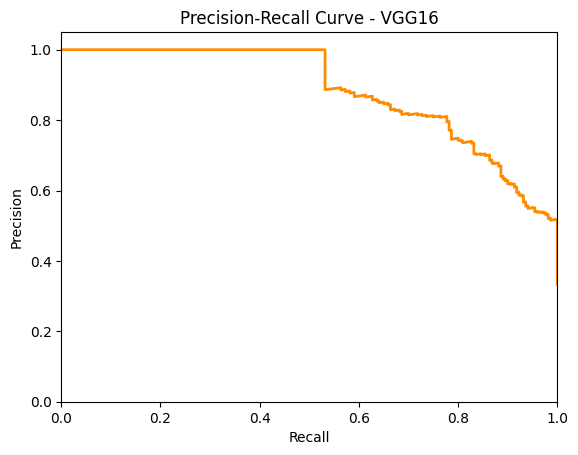

7/7 [==============================] - 0s 60ms/step


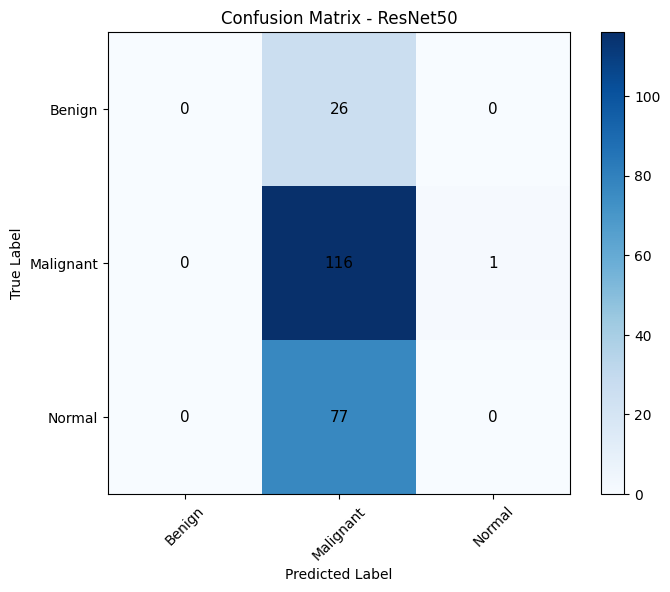

Classification Report - ResNet50:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00        26
   Malignant       0.53      0.99      0.69       117
      Normal       0.00      0.00      0.00        77

    accuracy                           0.53       220
   macro avg       0.18      0.33      0.23       220
weighted avg       0.28      0.53      0.37       220



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


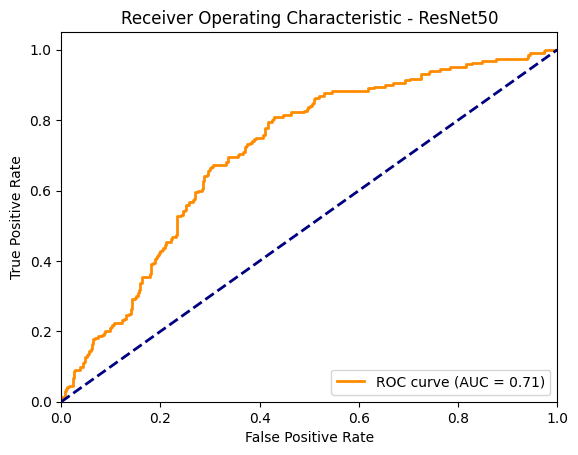

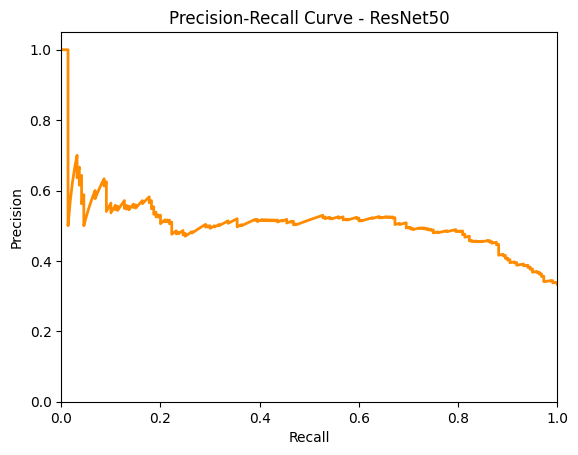

7/7 [==============================] - 0s 60ms/step


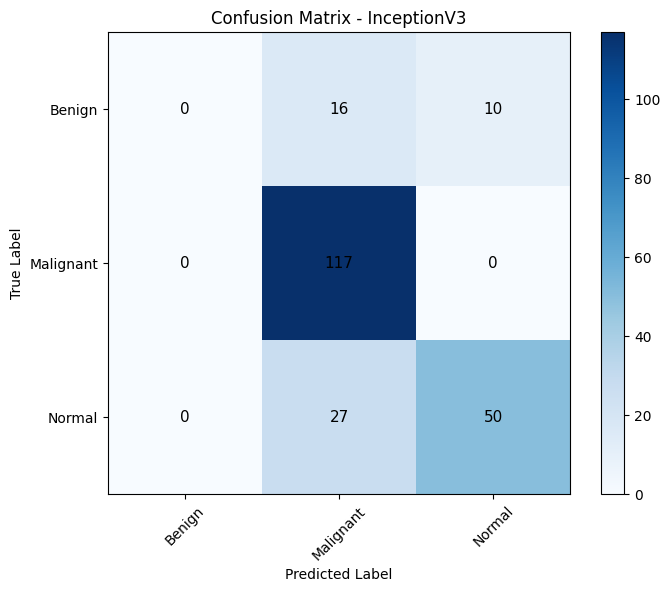

Classification Report - InceptionV3:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00        26
   Malignant       0.73      1.00      0.84       117
      Normal       0.83      0.65      0.73        77

    accuracy                           0.76       220
   macro avg       0.52      0.55      0.52       220
weighted avg       0.68      0.76      0.70       220



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


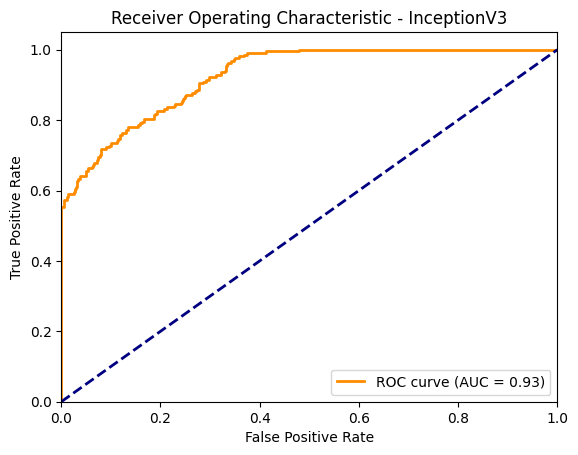

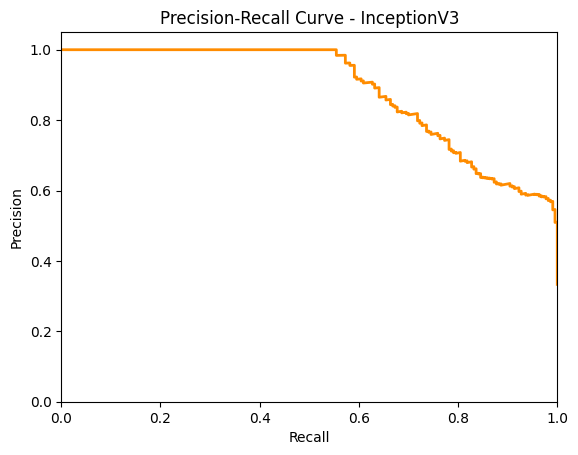

7/7 [==============================] - 0s 56ms/step


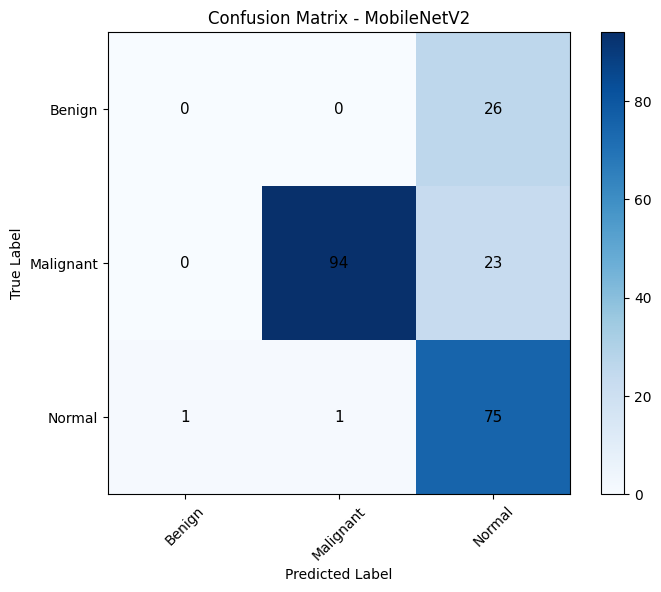

Classification Report - MobileNetV2:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00        26
   Malignant       0.99      0.80      0.89       117
      Normal       0.60      0.97      0.75        77

    accuracy                           0.77       220
   macro avg       0.53      0.59      0.54       220
weighted avg       0.74      0.77      0.73       220



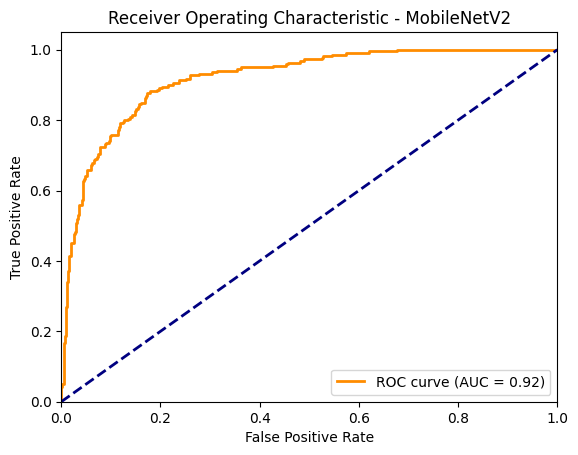

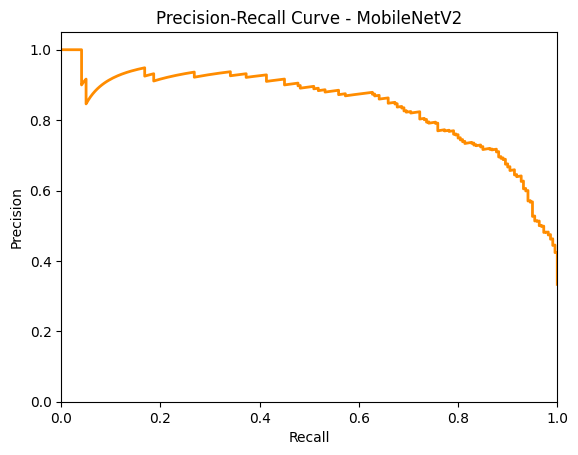

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have the true labels (y_true) and predicted labels (y_pred) for each model

# Confusion Matrix

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.colorbar()
    tick_marks = np.arange(len(unique_cancer))
    plt.xticks(tick_marks, unique_cancer, rotation=45)
    plt.yticks(tick_marks, unique_cancer)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    # Loop through each cell and print the value
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=11)

    plt.show()


'''
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.colorbar()
    tick_marks = np.arange(len(unique_cancer))
    plt.xticks(tick_marks, unique_cancer, rotation=45)
    plt.yticks(tick_marks, unique_cancer)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
'''

# Classification Report
def print_classification_report(y_true, y_pred, model_name):
    print(f"Classification Report - {model_name}:")
    print(classification_report(y_true, y_pred, target_names=unique_cancer))

# ROC Curve and AUC Score
def plot_roc_curve(y_true, y_pred_prob, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

# Precision-Recall Curve
def plot_precision_recall_curve(y_true, y_pred_prob, model_name):
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_prob)
    plt.figure()
    plt.plot(recall, precision, color='darkorange', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.show()

# Iterate over each model and generate evaluations
for model_name, model in [("LungCNET", lungCNET_model), ("VGG16", vgg16_model), ("ResNet50", resnet50_model),
                           ("InceptionV3", inceptionv3_model), ("MobileNetV2", mobilenetv2_model)]:
    # Get true labels and predicted labels for the model
    y_true = np.argmax(y_val, axis=-1)  # Convert true labels to multiclass format
    y_pred = np.argmax(model.predict(val_data), axis=-1)  # Predicted label indices for the validation set
    y_pred_labels = unique_cancer[y_pred]  # Convert predicted indices to class labels
    y_true_labels = unique_cancer[y_true]  # Convert true label indices to class labels
    y_pred_prob = model.predict(val_data)  # Predicted probabilities for the validation set

    # Confusion Matrix
    plot_confusion_matrix(y_true_labels, y_pred_labels, model_name)

    # Classification Report
    print_classification_report(y_true_labels, y_pred_labels, model_name)

    # ROC Curve and AUC Score
    y_true_binary = label_binarize(y_true_labels, classes=unique_cancer)
    plot_roc_curve(y_true_binary.ravel(), y_pred_prob.ravel(), model_name)

    # Precision-Recall Curve
    plot_precision_recall_curve(y_true_binary.ravel(), y_pred_prob.ravel(), model_name)